# MLP Classifier

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from taxonomy_separability import add_relative_features
from mlp_classifier import (
    apply_mlp_class_groups,
    run_training,
    evaluate_val_metrics,
    plot_training_curves,
    N_BINS,
    HIDDEN_DIM,
    LEARNING_RATE,
    EPOCHS,
    BATCH_SIZE,
)
from mlp_variants import run_variant
from split_sensitivity import run_split_sensitivity

## Build features

In [2]:
df = build_and_save_points_table()
df = add_relative_features(df)

/home/bruno/radar_machine_learning_ws/results/data/points_table.parquet already covers exactly the requested sequences, skipping build


## Architecture and training config

Shared across every taxonomy candidate compared below, only the number of output classes changes with the taxonomy.

**Architecture:** 3 layer MLP (2 hidden layers of 16 units each, ReLU), input 65 features, output one logit per class.

**Feature design:** per instance histogram encoding. `rcs`, `vr_compensated`, `x_rel`, `y_rel` each binned into N_BINS=16 fraction-of-points-per-bin columns (64 dims total), plus `doppler_spread` appended unbinned (1 dim), for 65 dims total. Bin edges use the 1st to 99th percentile range, fit on train only and reused unchanged for val/test.

**Batch size and learning rate:** decided against the original taxonomy, where `bus` made up only 1.9% of train instances (vs. 42.8% for car), rare enough to be absent from most batches at small batch sizes. `BATCH_SIZE=128` is the smallest candidate keeping every class's per-batch miss probability below 10%; the learning rate is scaled with it via the linear scaling rule, `lr = 1e-5 x (128/32) = 4e-5`. Rechecked after the taxonomy decision (`bs32` below), still holds. See `scripts/batch_size_selection.py`.

**Epochs:** `EPOCHS=50`, reasoning in the epoch count aside just below, alongside the `bus_separate` confusion matrix.

**Training:** Adam optimizer, class weighted cross entropy loss (weight = max class count / class count). RANDOM_STATE=0.

**Data:** fixed sequence grouped train/val/test split (`Design_Decisions.md` decision 5).

Full writeup: `MLP_Decisions_and_Findings.md`.

## Class taxonomy: how many vehicle classes

RadarScenes' raw labels are merged down to a working set before anything gets trained (`Design_Decisions.md` decision 1): `truck` is already folded into `large_vehicle`, `bicycle`/`motorized_two_wheeler` into `two_wheeler`. `bus` is the open question this section resolves, by comparing three candidates through the identical architecture and training config, not by guessing. `bus_separate` keeps `bus` as its own class, the original taxonomy (6 classes total). Both `baseline` and `truck_separate` below reuse the fixed split unchanged and are defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/bus_separate/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/bus_separate/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/bus_separate/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.935   0.727  0.818    31055
large_vehicle         0.426   0.582  0.492     4752
bus                   0.439   0.710  0.543     1495
two_wheeler           0.489   0.518  0.503     4629
pedestrian            0.552   0.857  0.672    11325
pedestrian_group      0.683   0.595  0.636    17858


Saved /home/bruno/radar_machine_learning_ws/results/mlp/bus_separate/mlp_confusion_matrix.png
Saved /home/bruno/radar_machine_learning_ws/results/mlp/bus_separate/mlp_precision_recall_f1.png


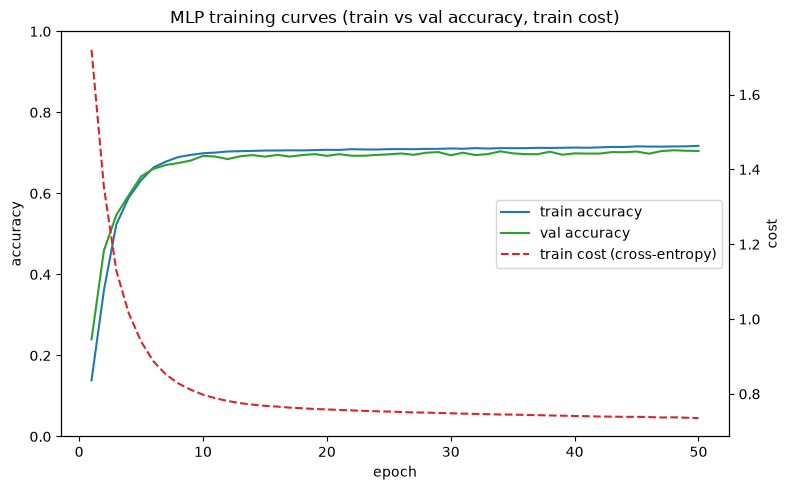

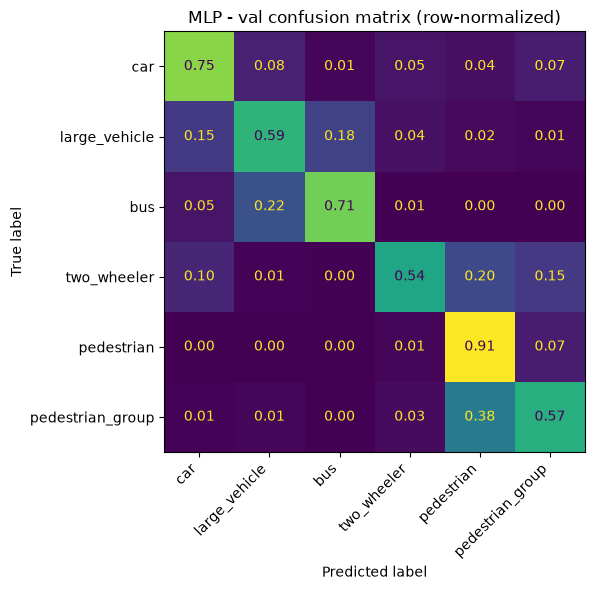

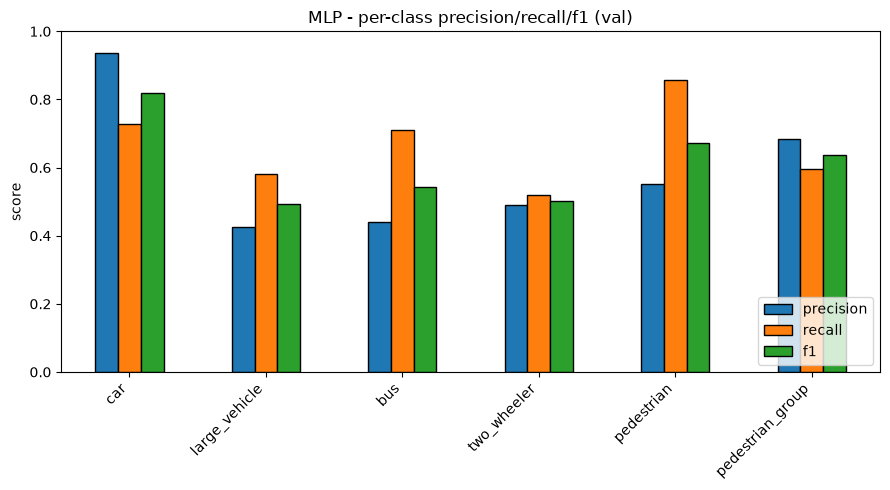

In [3]:
# cached, no retraining
_, _, bus_separate_metrics, bus_separate_cm, _ = run_variant(df, "bus_separate")

### bus_separate confusion matrix (original 6-class taxonomy)

Row-normalized, val set:

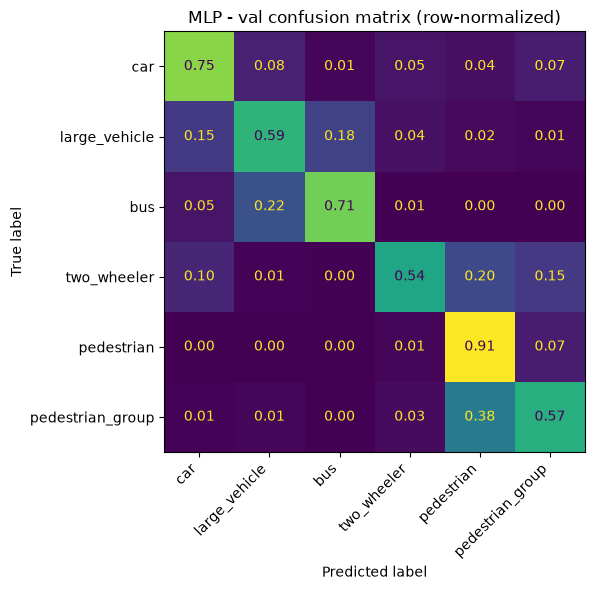

In [4]:
bus_separate_cm

- `car`: 73% correct, the most accurate label and the majority class. 10% confused as `large_vehicle`.
- `large_vehicle`: confused as `car` and `bus`.
- `bus`: confused as `large_vehicle`.
- `two_wheeler`: confused as `pedestrian` and `pedestrian_group`.
- `pedestrian`: recall high.
- `pedestrian_group`: confused a lot into `pedestrian`, expected given point sparsity, an isolated pedestrian and a sparse group can look similar with few points to work with.

The confusion isn't scattered, it clusters within car/large_vehicle/bus (all "vehicle" classes) and separately within pedestrian/pedestrian_group, rather than spreading across unrelated classes. That pattern reads more like a feature-separability ceiling (the histogram features can't fully tell `bus` and `large_vehicle` apart) than gradient starvation, and is in tension with a starvation story: `bus`'s recall (71%) is *higher* than `two_wheeler`'s (52%) despite `bus` being the far rarer class (1.9% vs 7.0% of train). A separate check training this exact config for 1000 epochs instead of 50 supports this too, `bus`'s F1 got slightly *worse* with more training while other classes improved, more consistent with a ceiling than with undertraining (full numbers: `MLP_Decisions_and_Findings.md` section 2, results at `results/mlp/epochs_1000/`, not re-run in this notebook).

This motivated testing whether merging `bus` into `large_vehicle` actually helps, and whether `truck` should stay merged too, rather than assuming either.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.784  0.854    31055
large_vehicle         0.719   0.797  0.756     6247
two_wheeler           0.475   0.545  0.508     4629
pedestrian            0.534   0.944  0.682    11325
pedestrian_group      0.754   0.544  0.632    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/class_taxonomy_experiment/truck_separate/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/class_taxonomy_experiment/truck_separate/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/class_taxonomy_experiment/truck_separate/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.947   0.701  0.806    31055
large_vehicle         0.059   0.297  0.098     1244
truck                 0.523   0.572  0.546     3508
bus                   0.435   0.696  0.535     1495
two_wheeler           0.495   0.530  0.512     4629
pedestrian            0.539   0.931  0.683    11325
pedestrian_group      0.796   0.495  0.610    17858


Saved /home/bruno/radar_machine_learning_ws/results/mlp/class_taxonomy_experiment/truck_separate/mlp_confusion_matrix.png
Saved /home/bruno/radar_machine_learning_ws/results/mlp/class_taxonomy_experiment/truck_separate/mlp_precision_recall_f1.png


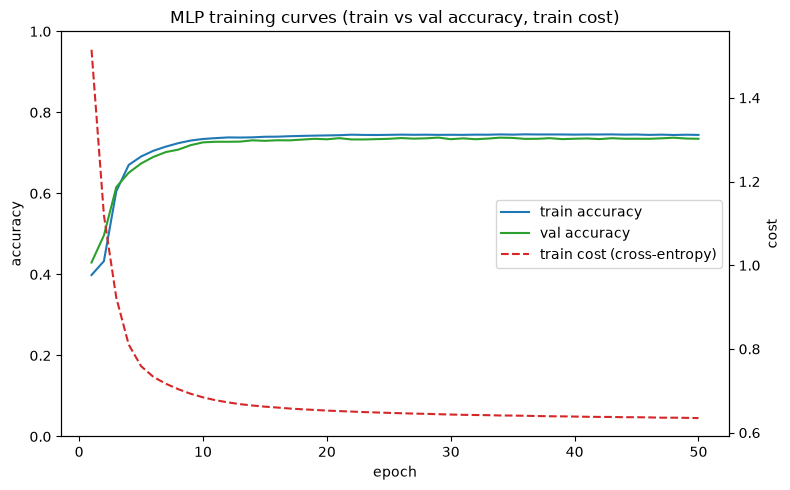

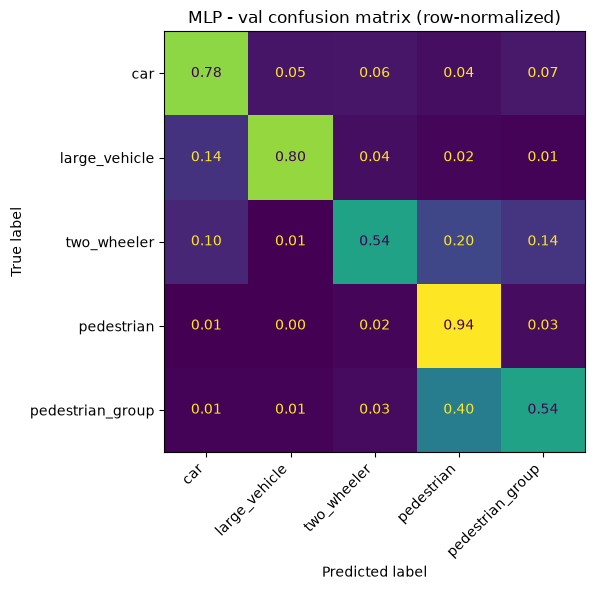

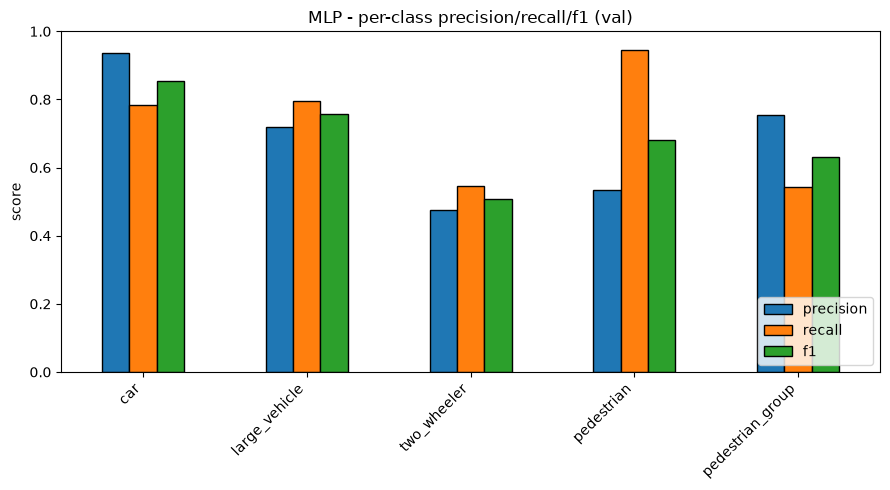

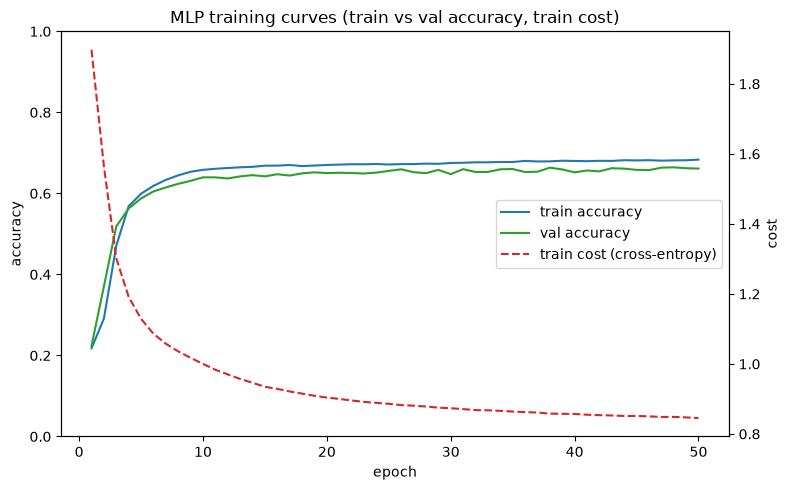

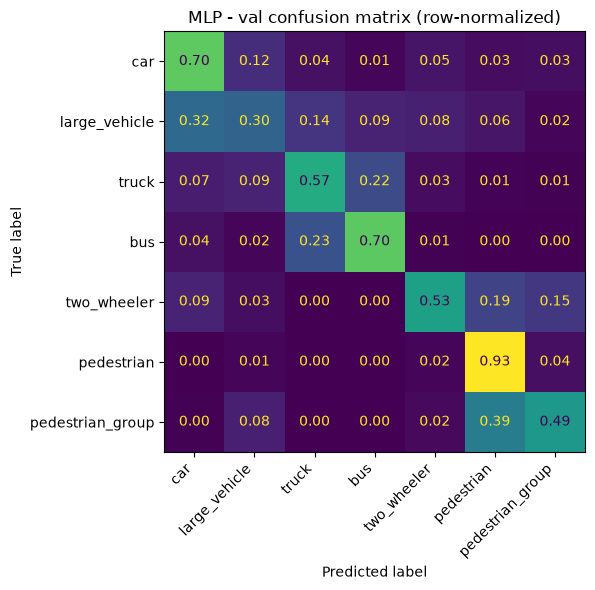

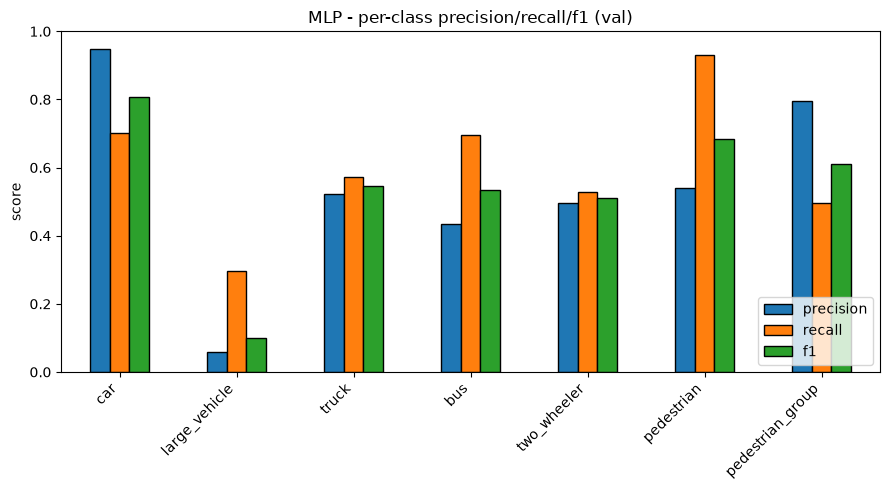

In [5]:
# both cached, no retraining
_, _, baseline_metrics, _, _ = run_variant(df, "baseline")
_, _, truck_separate_metrics, _, _ = run_variant(df, "truck_separate")

In [6]:
baseline_metrics

,precision,recall,f1,support
car,0.937115,0.784093,0.853802,31055
large_vehicle,0.719491,0.796542,0.756059,6247
two_wheeler,0.475302,0.544610,0.507601,4629
pedestrian,0.533806,0.943929,0.681956,11325
pedestrian_group,0.754346,0.544238,0.632295,17858


In [7]:
truck_separate_metrics

,precision,recall,f1,support
car,0.947199,0.701272,0.805891,31055
large_vehicle,0.058955,0.297428,0.098404,1244
truck,0.522816,0.571551,0.546098,3508
bus,0.434656,0.696321,0.535219,1495
two_wheeler,0.495253,0.529704,0.511900,4629
pedestrian,0.538926,0.930949,0.682660,11325
pedestrian_group,0.796073,0.494904,0.610359,17858


Macro F1: `bus_separate` (original 6 classes) 0.611, bus merged (5 classes, `baseline`) 0.686, `truck_separate` (7 classes) 0.541.

Bus merged: folding `bus` into `large_vehicle` raises the combined class to F1=0.756, above either `bus` (0.543) or `large_vehicle` (0.492) alone in `bus_separate`. `truck_separate`: splitting `truck` back out leaves pure `large_vehicle` at only 1,292 train instances, nearly unusable (F1=0.098), confirming the `truck` merge was already correct.

**Decision:** use the 5-class taxonomy, `bus` merged into `large_vehicle`. This is `mlp_variants.py`'s `baseline` and `mlp_classifier.py`'s own default from here on. Full writeup: `MLP_Decisions_and_Findings.md` sections 3 and 4.

In [8]:
df = apply_mlp_class_groups(df)

## Train baseline (cached)

`run_training` loads the cached model/history if this exact config was already run, it does not retrain.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


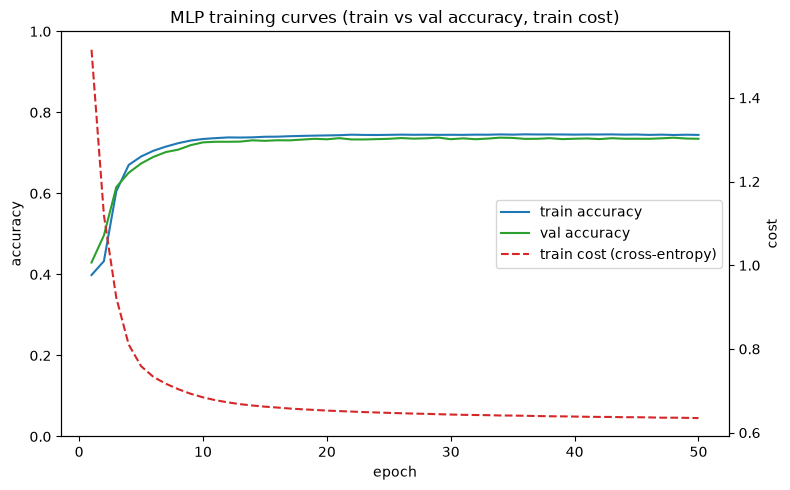

In [9]:
# uses cached model + history if EPOCHS/BATCH_SIZE/LEARNING_RATE match a prior run - no retraining
model, history, X_test, y_test = run_training(df)

## Validation metrics (cached)

Per-class precision/recall/f1, confusion matrix, and a precision/recall/f1 bar chart, computed from the cached model only, never retrains.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.784  0.854    31055
large_vehicle         0.719   0.797  0.756     6247
two_wheeler           0.475   0.545  0.508     4629
pedestrian            0.534   0.944  0.682    11325
pedestrian_group      0.754   0.544  0.632    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_precision_recall_f1.png


,precision,recall,f1,support
car,0.937115,0.784093,0.853802,31055
large_vehicle,0.719491,0.796542,0.756059,6247
two_wheeler,0.475302,0.544610,0.507601,4629
pedestrian,0.533806,0.943929,0.681956,11325
pedestrian_group,0.754346,0.544238,0.632295,17858


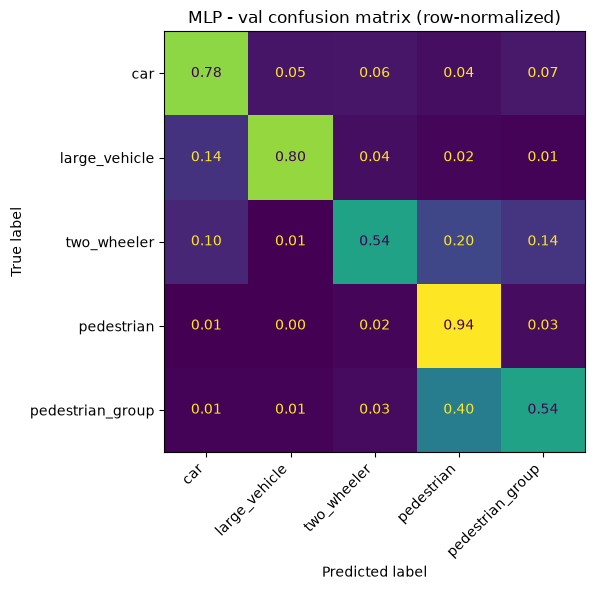

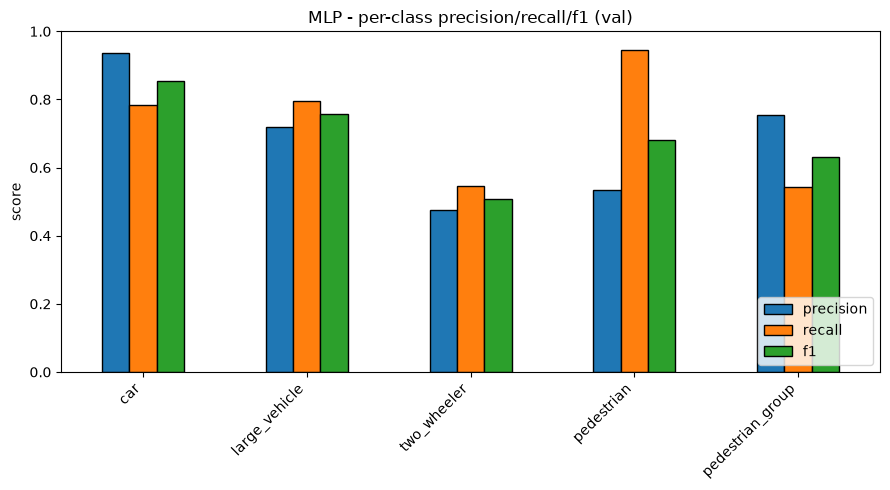

In [10]:
metrics_df, cm_fig, bar_fig = evaluate_val_metrics(df)
metrics_df

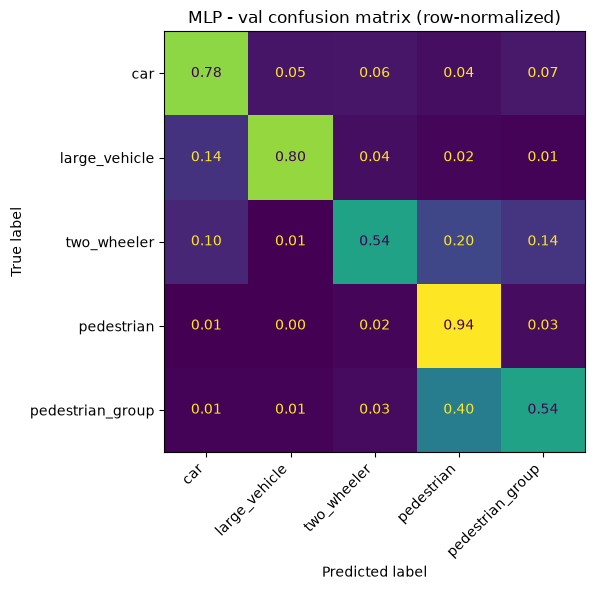

In [11]:
cm_fig

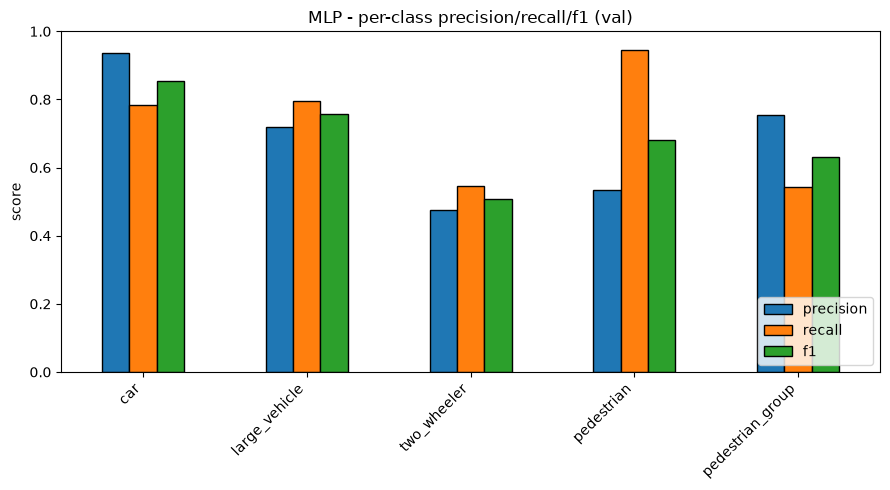

In [12]:
bar_fig

## Feature swap: range_sc

Same architecture/training config as `baseline`, but `range_sc` (per point sensor range) binned into the same N_BINS=16 columns used for `rcs`/`vr_compensated`/`x_rel`/`y_rel`, instead of `doppler_spread` appended unbinned. `bs32` separately rechecks `BATCH_SIZE`/`LEARNING_RATE` now that bus, the original binding constraint, is merged into `large_vehicle`. Both defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.939   0.771  0.847    31055
large_vehicle         0.655   0.797  0.719     6247
two_wheeler           0.501   0.641  0.563     4629
pedestrian            0.590   0.861  0.700    11325
pedestrian_group      0.743   0.648  0.692    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.782  0.852    31055
large_vehicle         0.717   0.791  0.753     6247
two_wheeler           0.488   0.541  0.513     4629
pedestrian            0.540   0.934  0.684    11325
pedestrian_group      0.731   0.555  0.631    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_precision_recall_f1.png


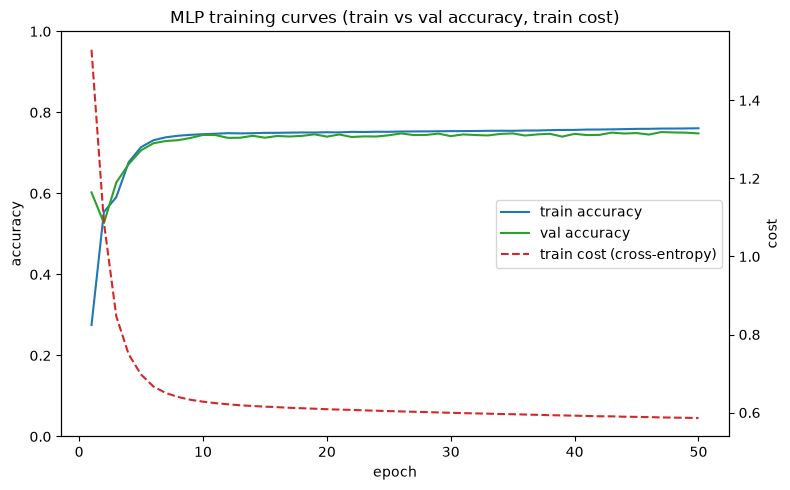

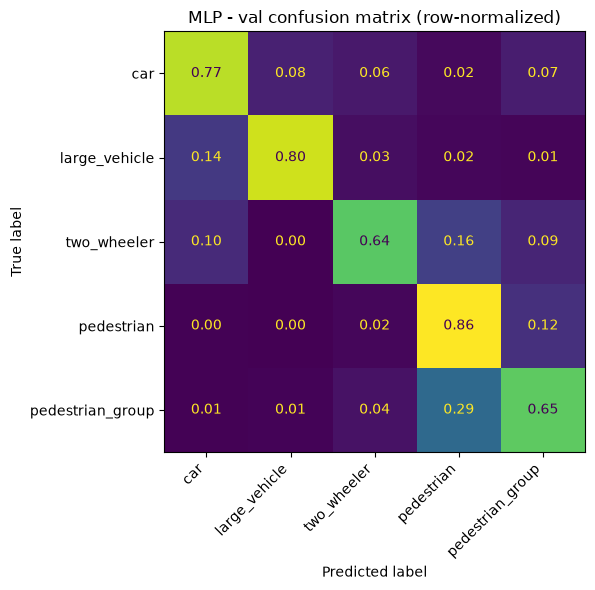

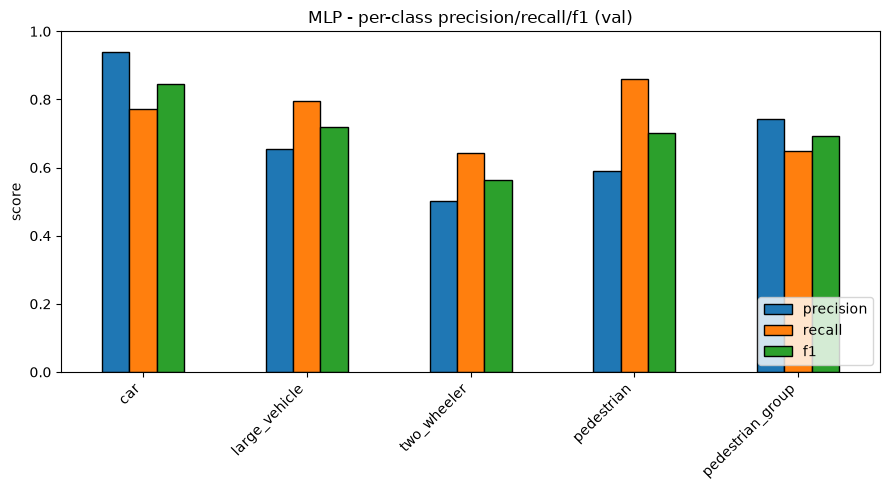

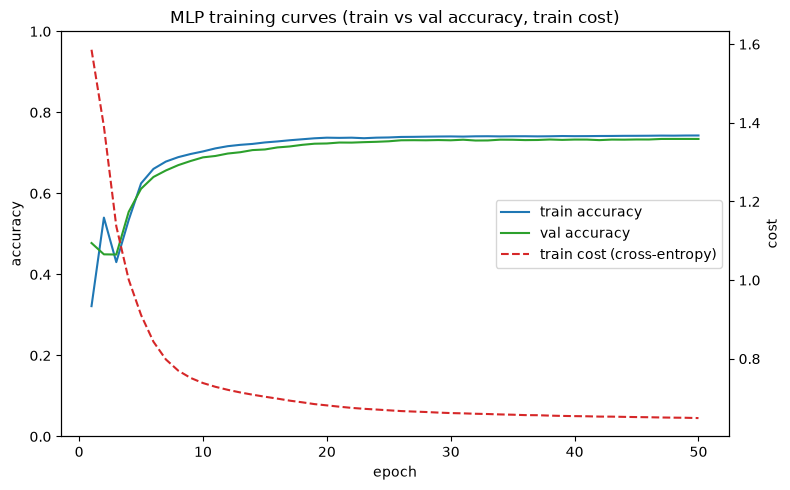

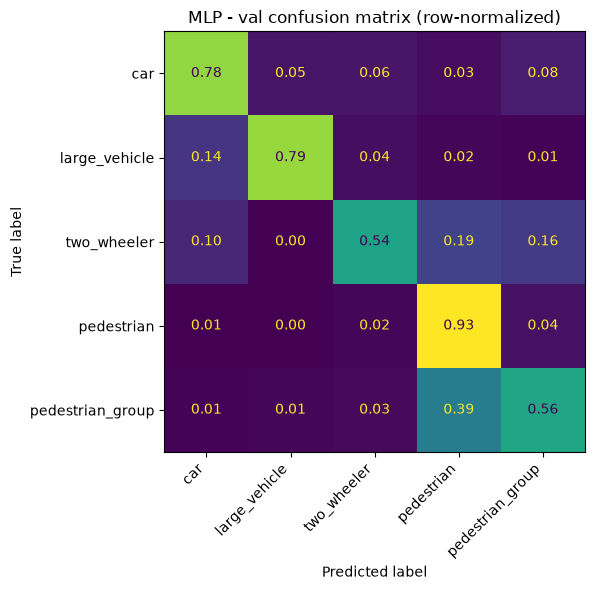

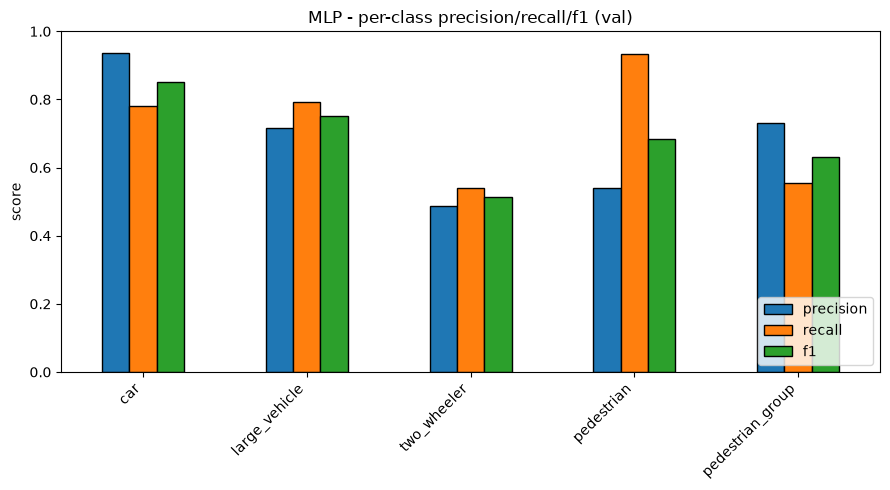

In [13]:
# both cached, no retraining
_, _, range_sc_metrics, _, _ = run_variant(df, "range_sc")
_, _, bs32_metrics, _, _ = run_variant(df, "bs32")

In [14]:
range_sc_metrics

,precision,recall,f1,support
car,0.939141,0.770697,0.846622,31055
large_vehicle,0.654914,0.796862,0.718949,6247
two_wheeler,0.501182,0.641391,0.562684,4629
pedestrian,0.590084,0.860662,0.700140,11325
pedestrian_group,0.742590,0.648113,0.692142,17858


In [15]:
bs32_metrics

,precision,recall,f1,support
car,0.936661,0.781903,0.852314,31055
large_vehicle,0.717458,0.791420,0.752626,6247
two_wheeler,0.488204,0.540938,0.513220,4629
pedestrian,0.539525,0.934128,0.683994,11325
pedestrian_group,0.731161,0.555269,0.631190,17858


Macro F1: `baseline` 0.686, `range_sc` 0.704, `bs32` 0.687. `range_sc` initially looked better, but see the split sensitivity check below: that gap is within normal split-to-split noise, not a real improvement. `bs32` is essentially identical to `baseline`, `BATCH_SIZE=128` stays.

Full writeup: `MLP_Decisions_and_Findings.md` section 5.

## Split sensitivity check

Is a macro F1 difference like `range_sc`'s (0.018 vs `baseline`) real, or just noise from which sequences happen to land in val? Tried picking a "better" val set by generating the 6 distinct valid splits at the fixed 70/15/15 proportions and scoring each by how closely train and val's per-class feature distributions matched (two-sample Kolmogorov-Smirnov statistic), then trained `baseline`'s exact config on all 6.

`scripts/split_sensitivity.py`, results at `results/mlp/split_search/fold_<n>/`.

 random_state  fold  n_val_sequences  mean_ks  max_ks
            0     0               22   0.0557  0.1793
            1     0               22   0.0557  0.1793
            2     0               22   0.0557  0.1793
            3     0               22   0.0557  0.1793
            4     0               22   0.0557  0.1793
            5     0               22   0.0557  0.1793
            6     0               22   0.0557  0.1793
            7     0               22   0.0557  0.1793
            8     0               22   0.0557  0.1793
            9     0               22   0.0557  0.1793
            0     2               19   0.0588  0.2857
            1     2               19   0.0588  0.2857
            2     2               19   0.0588  0.2857
            3     2               19   0.0588  0.2857
            4     2               19   0.0588  0.2857
            5     2               19   0.0588  0.2857
            6     2               19   0.0588  0.2857
            7     2         

/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.930   0.807  0.864    31363
large_vehicle         0.726   0.709  0.717     6243
two_wheeler           0.474   0.753  0.582     4720
pedestrian            0.502   0.915  0.648    11074
pedestrian_group      0.781   0.465  0.583    18757
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_precision_recall_f1.png
fold 0 macro F1: 0.6788
=== fold 1 (max_ks=0.6238) ===


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_1/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_1/mlp_training_curves.png


...

Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_4/mlp_precision_recall_f1.png
fold 4 macro F1: 0.6953
=== fold 5 (max_ks=0.2870) ===


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.949   0.812  0.875    29555
large_vehicle         0.764   0.866  0.812     6312
two_wheeler           0.405   0.669  0.505     4831
pedestrian            0.538   0.919  0.679    11605
pedestrian_group      0.805   0.443  0.572    17668
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_precision_recall_f1.png
fold 5 macro F1: 0.6884

macro F1 range: 0.651 - 0.734, std: 0.027
 fold   max_ks  macro_f1
    0 0.179348  0.678828
    1 0.623832  0.734235
    2 0.285685  0.700931
    3 0.336050  0.651298
    4 0.286753  0.695262
    5 0.287041  0.688433


,fold,max_ks,macro_f1
0,0,0.179348,0.678828
1,1,0.623832,0.734235
2,2,0.285685,0.700931
3,3,0.336050,0.651298
4,4,0.286753,0.695262
5,5,0.287041,0.688433


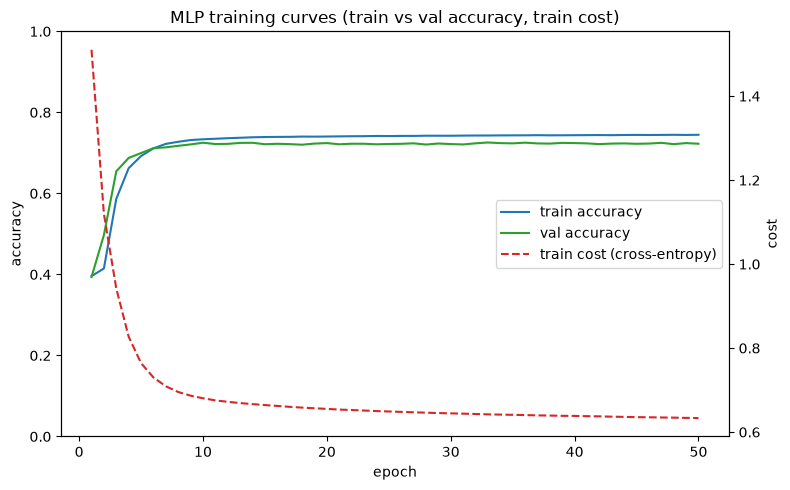

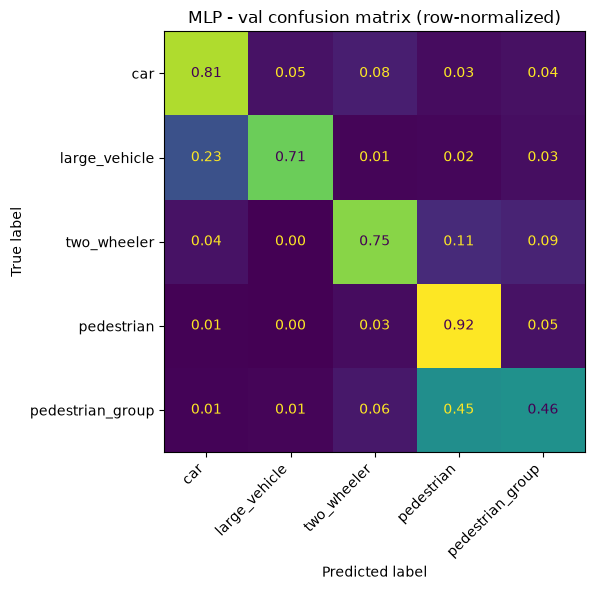

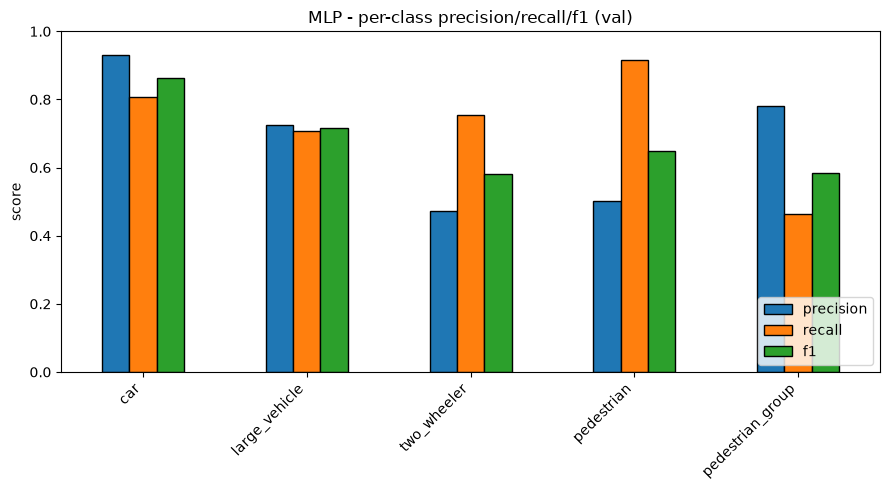

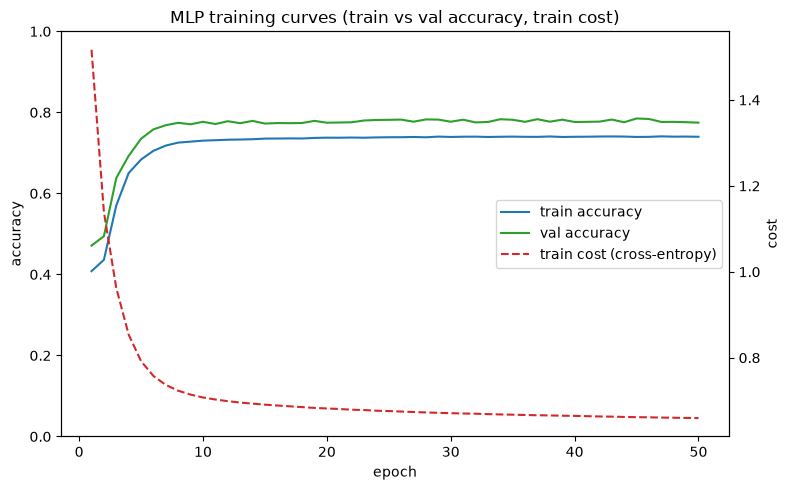

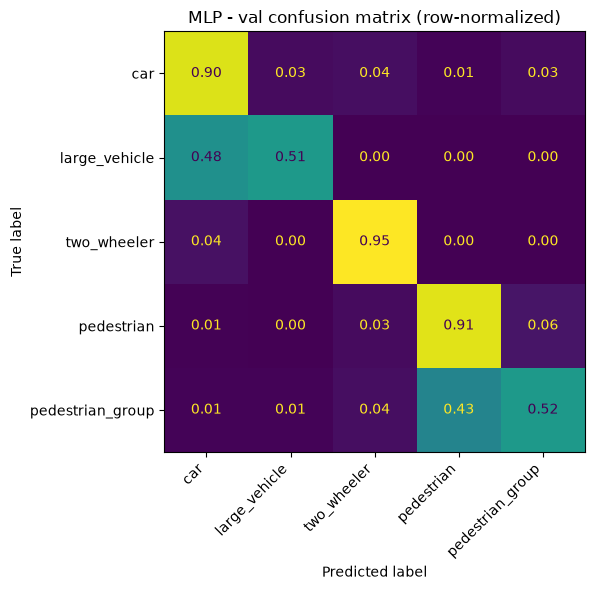

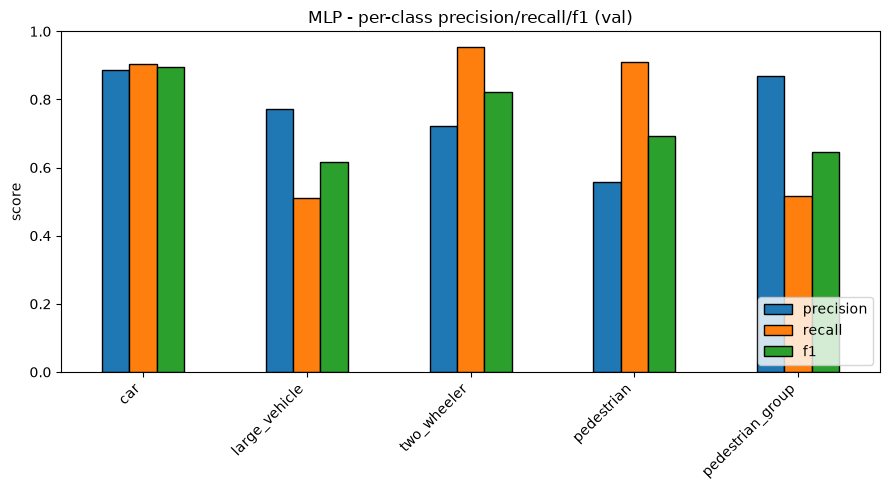

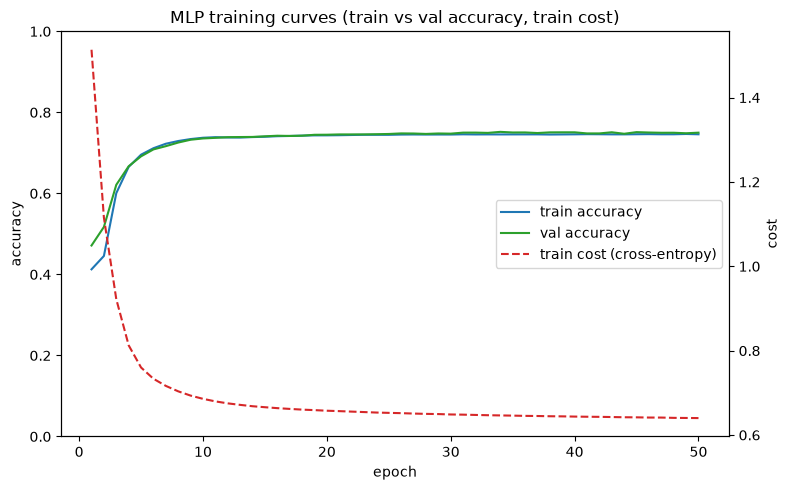

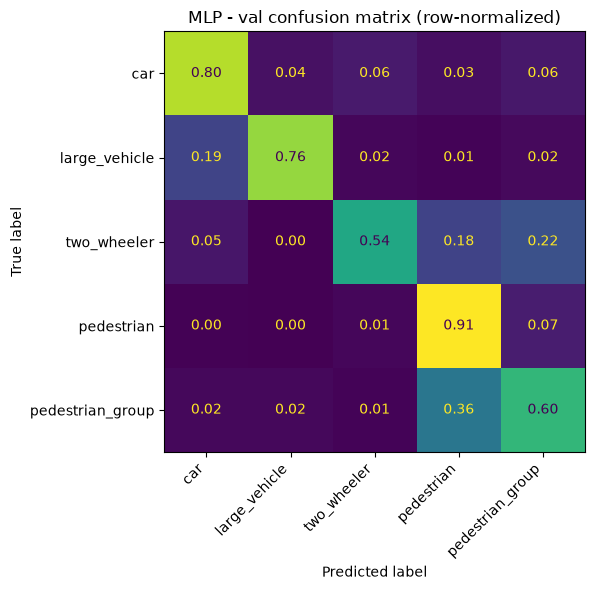

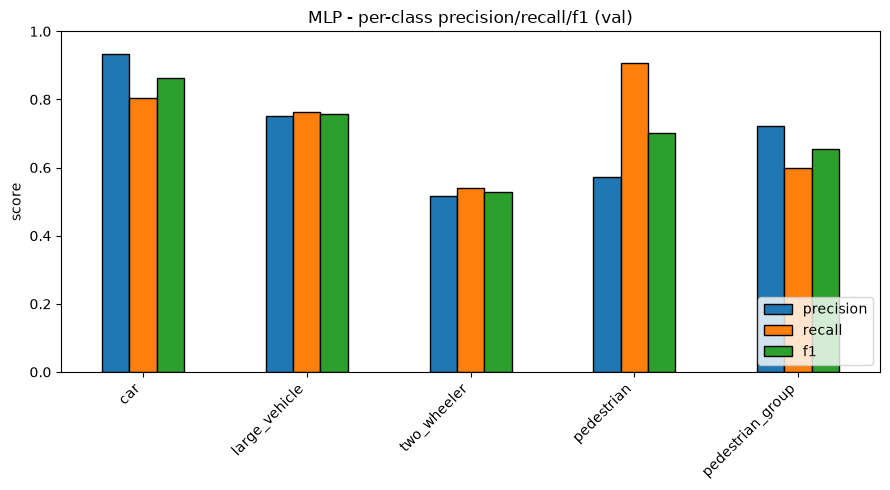

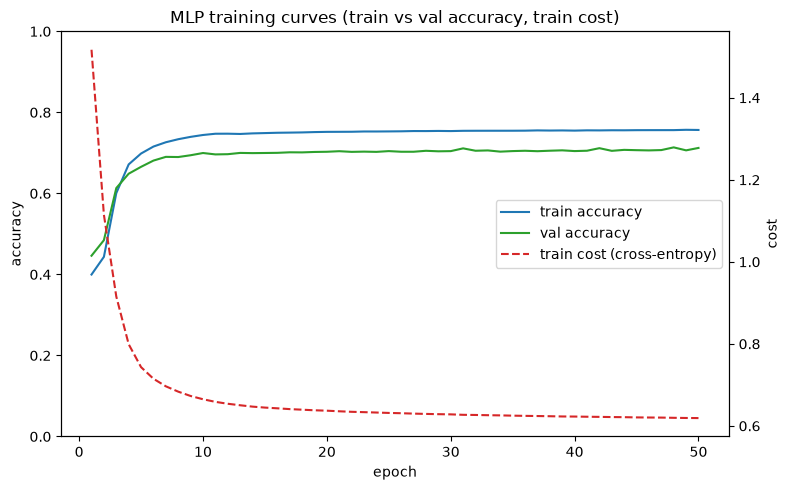

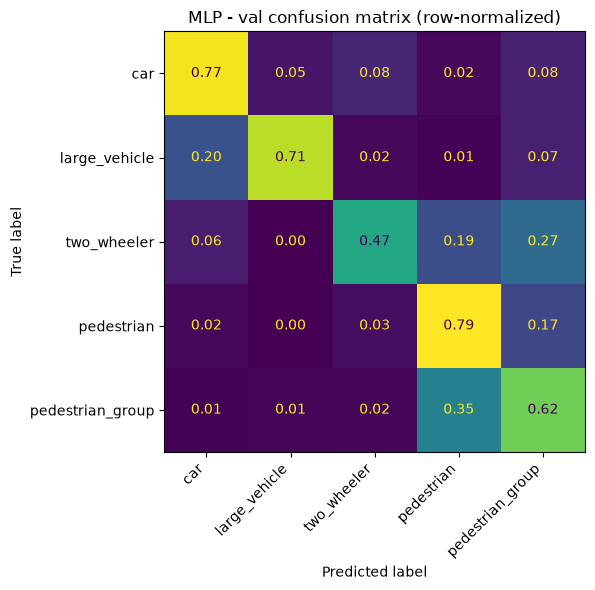

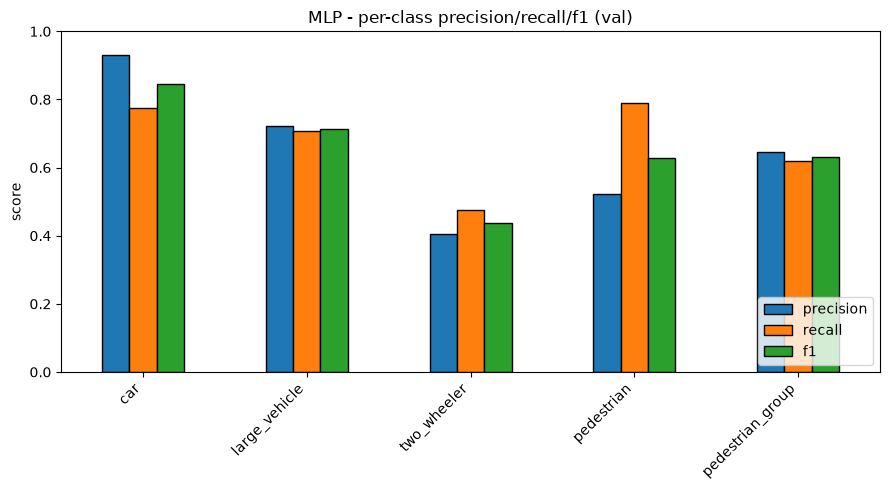

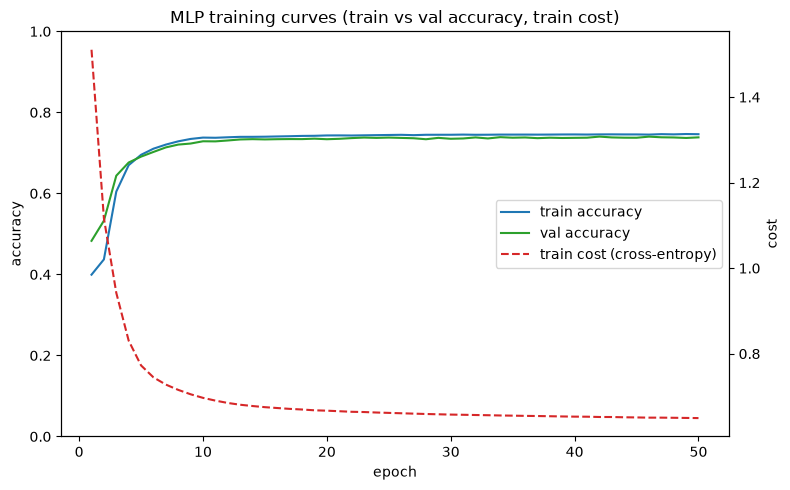

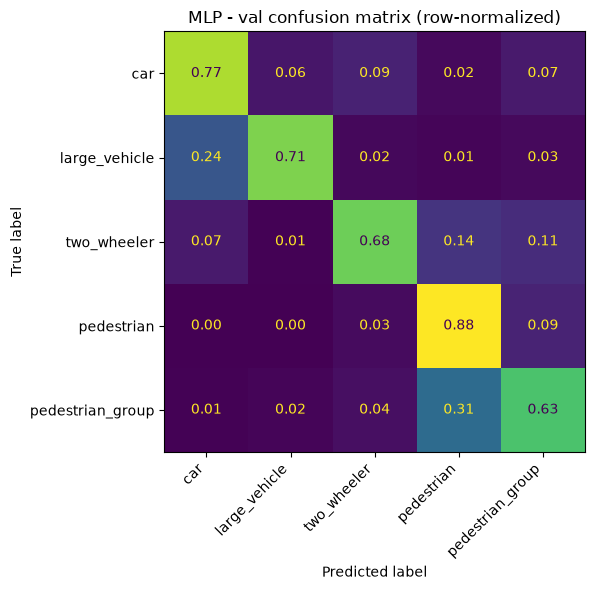

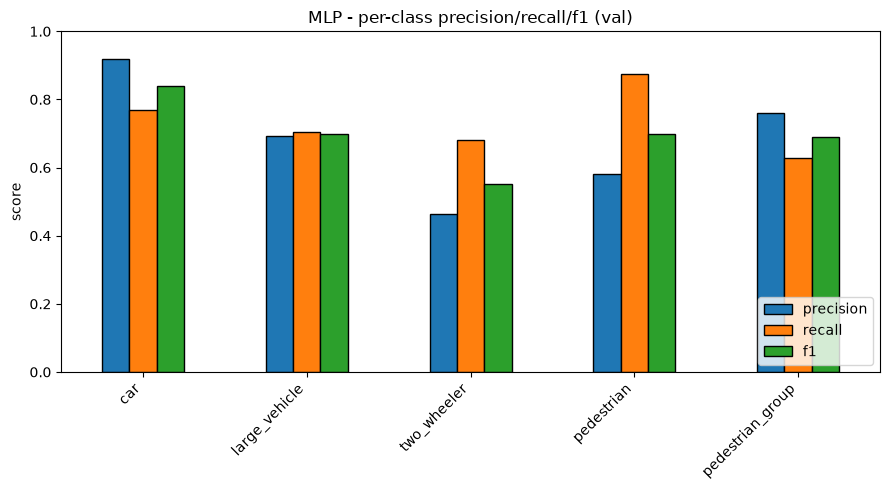

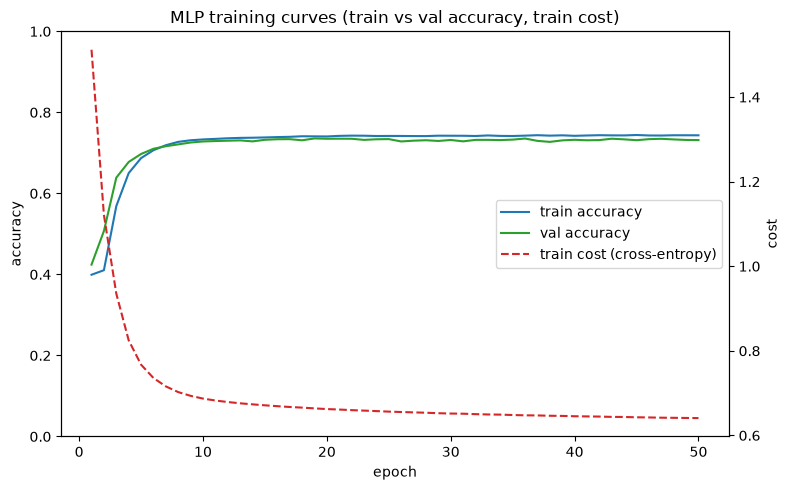

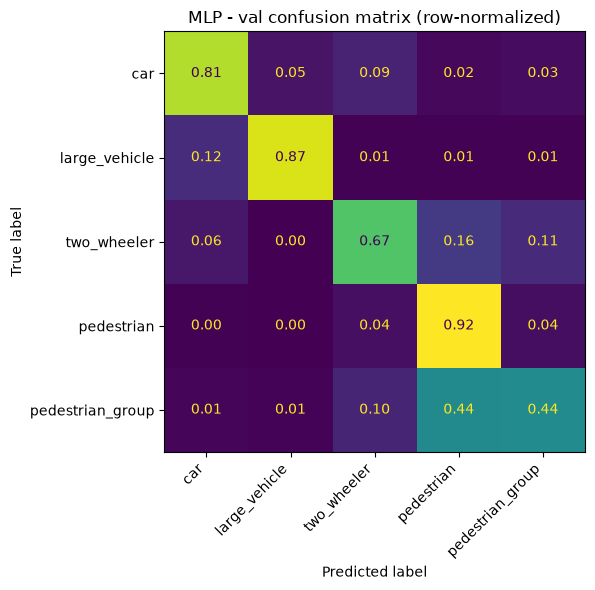

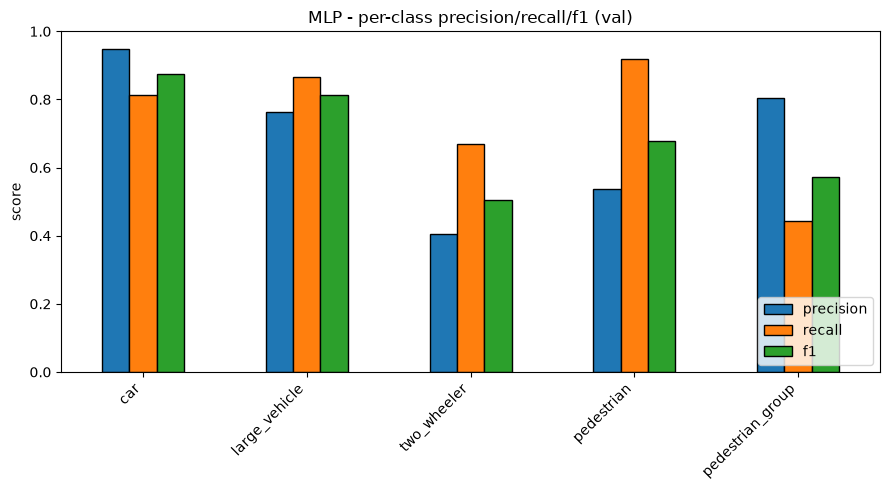

In [16]:
# cached - reruns the KS scoring (cheap) and loads each fold's cached model, no retraining
split_summary = run_split_sensitivity(df)
split_summary

Macro F1 ranged 0.651 to 0.734 across the 6 splits, purely from which sequences landed in val, wider than the `range_sc` gap (0.018). The split with the best-matching train/val distributions actually scored near the worst, and the worst-matching one scored best, so distribution match didn't predict model performance either.

**Decision:** keep the standing split, no candidate is a demonstrated improvement. The `range_sc` vs `baseline` comparison is closed as noise, not a real gain.

Root cause, briefly: a sequence-grouped split can't guarantee a class's radar signature (aspect angle, motion state) is well mixed between train and val when that class is concentrated in a handful of sequences, e.g. a bicycle stopped at a light (near-zero Doppler, narrow RCS) versus one crossing broadside (also near-zero Doppler, but much larger RCS) are the same label with very different feature distributions. Full writeup, including the sequence-concentration mechanism and general lesson for future projects: `MLP_Decisions_and_Findings.md`, Key takeaways.

## Architecture capacity: hidden_dim ablation

Is the 16-unit hidden layer actually a bottleneck, or does the histogram feature representation cap performance regardless of model size? Same architecture shape (2 hidden layers), same features/taxonomy/batch size/LR/epochs as `baseline`, only `hidden_dim` changes: 8, 32, 64, against the standing 16. Defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.942   0.786  0.857    31055
large_vehicle         0.705   0.797  0.748     6247
two_wheeler           0.485   0.537  0.509     4629
pedestrian            0.553   0.877  0.679    11325
pedestrian_group      0.709   0.597  0.648    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.784  0.854    31055
large_vehicle         0.719   0.797  0.756     6247
two_wheeler           0.475   0.545  0.508     4629
pedestrian            0.534   0.944  0.682    11325
pedestrian_group      0.754   0.544  0.632    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png


...

Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden32/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.939   0.786  0.856    31055
large_vehicle         0.681   0.805  0.738     6247
two_wheeler           0.469   0.561  0.511     4629
pedestrian            0.558   0.853  0.674    11325
pedestrian_group      0.725   0.603  0.659    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_precision_recall_f1.png


,variant,hidden_dim,macro_f1
0,hidden8,8,0.688272
1,baseline,16,0.686342
2,hidden32,32,0.687698
3,hidden64,64,0.687536


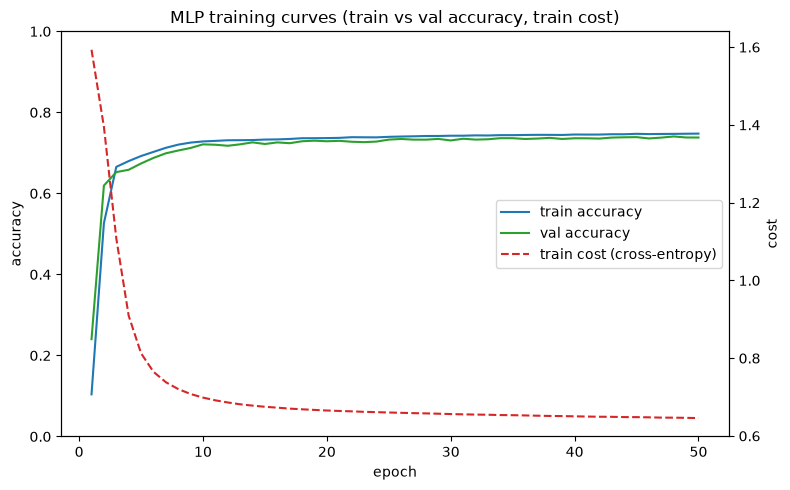

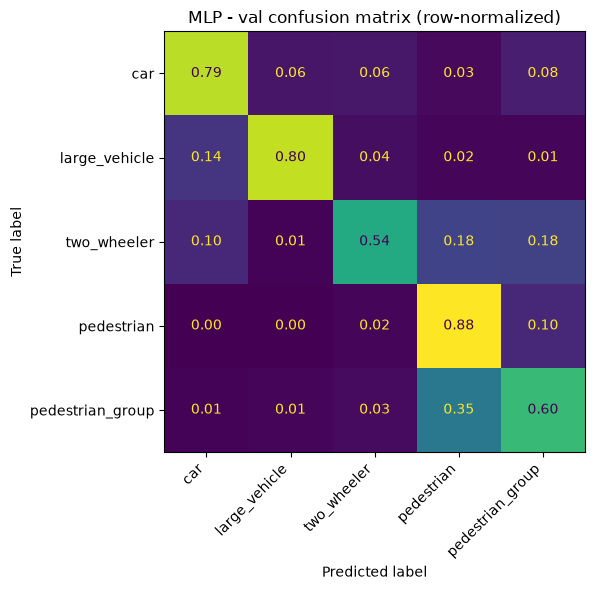

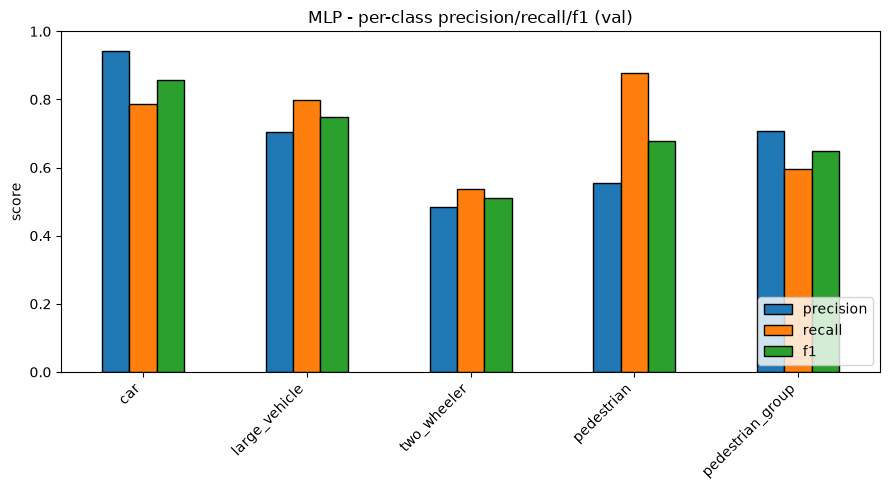

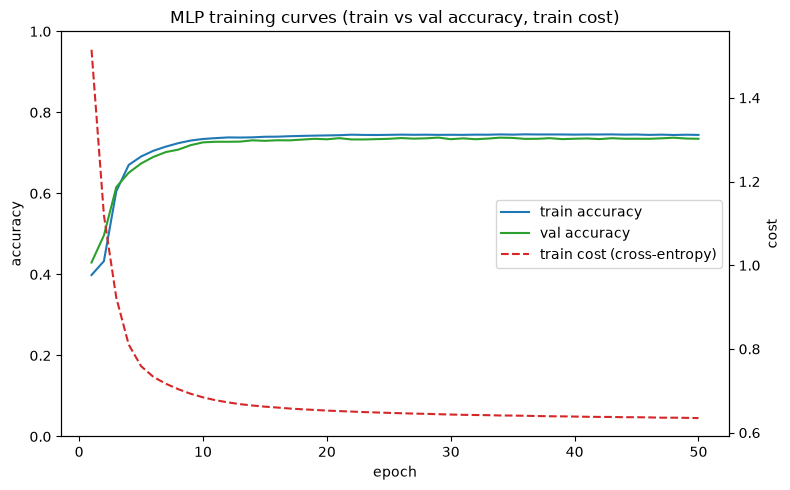

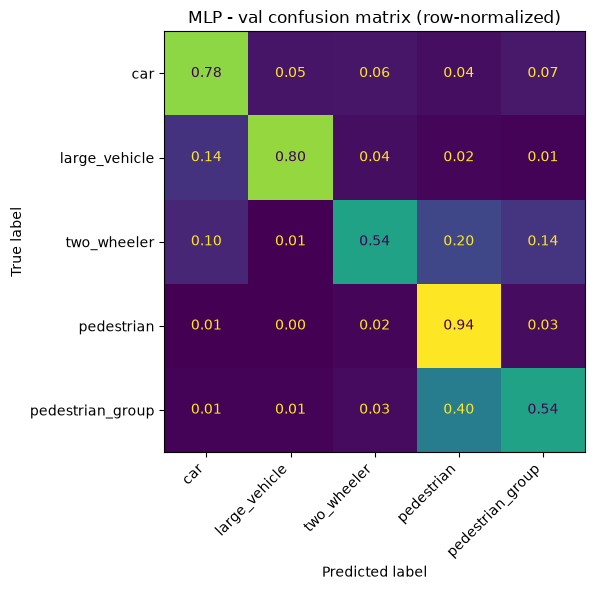

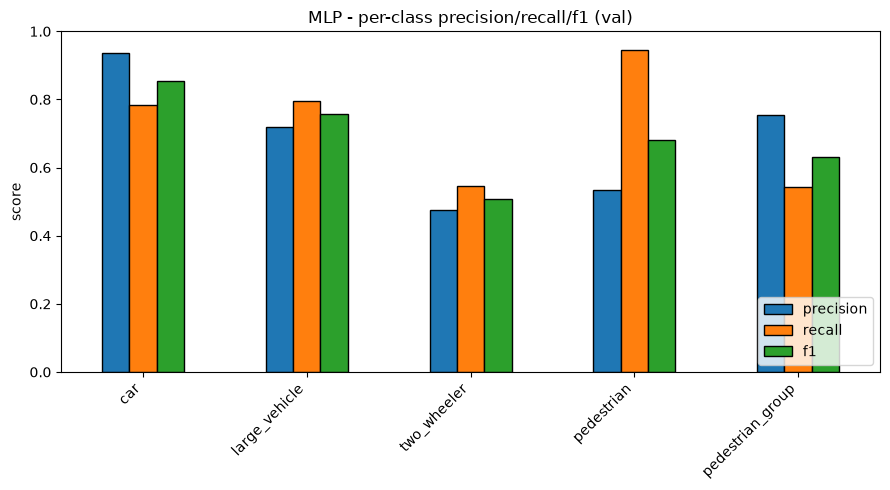

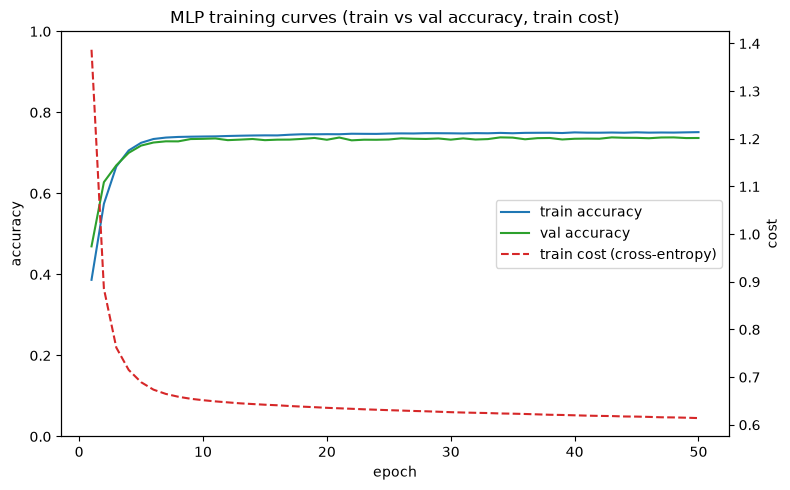

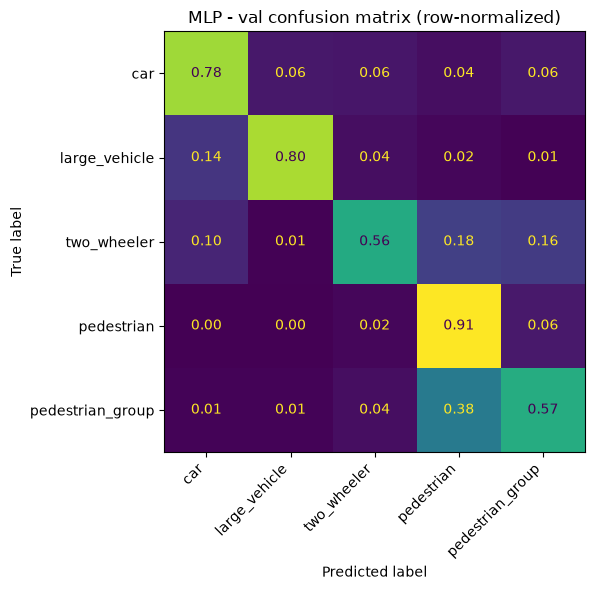

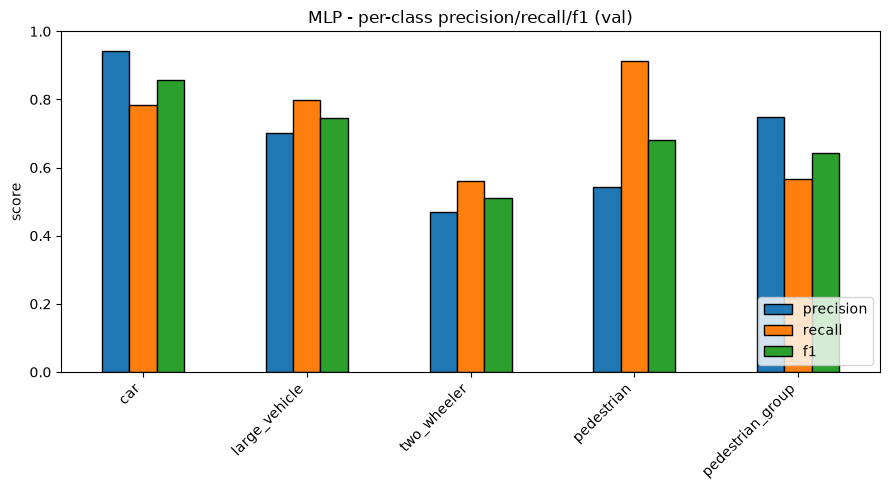

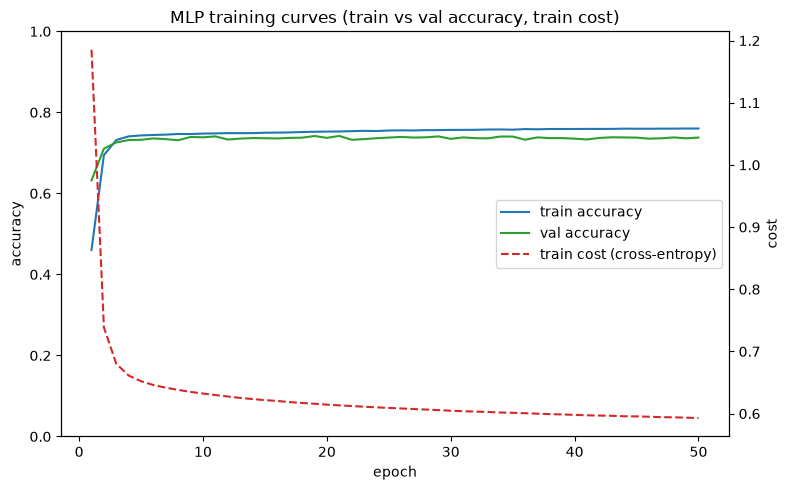

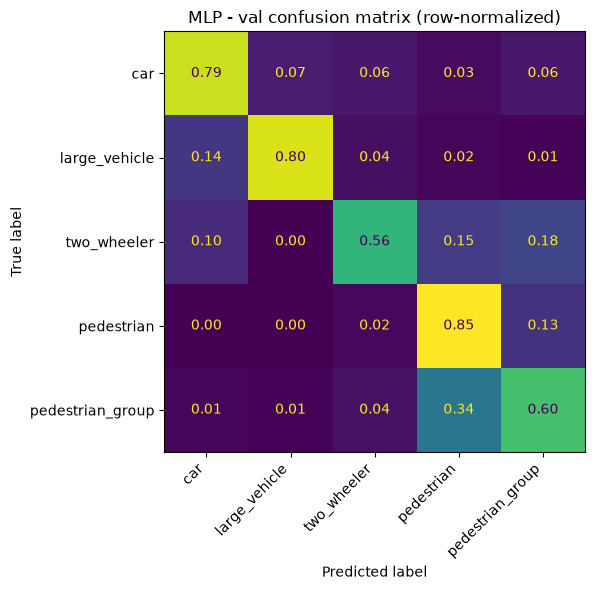

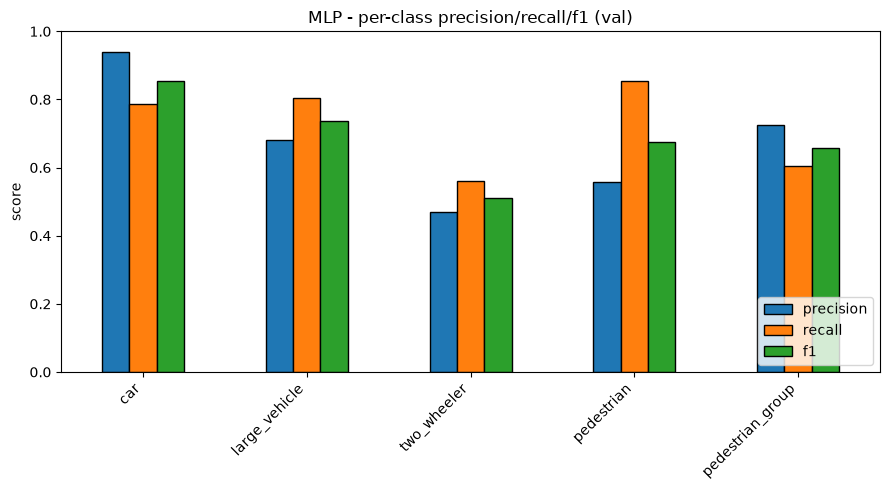

In [17]:
# all cached, no retraining
hidden_dims = {"hidden8": 8, "baseline": 16, "hidden32": 32, "hidden64": 64}
hidden_rows = []
for variant, dim in hidden_dims.items():
    _, _, m, _, _ = run_variant(df, variant)
    hidden_rows.append({"variant": variant, "hidden_dim": dim, "macro_f1": m["f1"].mean()})

import pandas as pd
pd.DataFrame(hidden_rows)

Macro F1: 0.688 (`hidden8`), 0.686 (`baseline`, 16), 0.688 (`hidden32`), 0.688 (`hidden64`), all within 0.002 of each other, far inside the measured noise floor (std 0.027 from the split sensitivity check above). Going from 8 to 64 units, an 8x range, moves nothing.

**Finding:** the model isn't capacity-limited. The histogram feature representation is the ceiling, not the network's expressive power, consistent with the feature-separability-ceiling read of the `bus`/`large_vehicle` confusion earlier in this notebook.

**Decision:** retain `HIDDEN_DIM=16`, no reason to spend more compute on a larger model for no measurable gain.

Full writeup: `MLP_Decisions_and_Findings.md` section 6.

### Per-class check: is capacity hiding behind the macro average?

Macro F1 could be flat while individual classes trade off against each other. Checked directly, and cross-checked against the per-class spread already measured from split choice alone (the split sensitivity table above), since that's the real noise floor to judge against, not intuition.

/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.942   0.786  0.857    31055
large_vehicle         0.705   0.797  0.748     6247
two_wheeler           0.485   0.537  0.509     4629
pedestrian            0.553   0.877  0.679    11325
pedestrian_group      0.709   0.597  0.648    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.784  0.854    31055
large_vehicle         0.719   0.797  0.756     6247
two_wheeler           0.475   0.545  0.508     4629
pedestrian            0.534   0.944  0.682    11325
pedestrian_group      0.754   0.544  0.632    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png


...

/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.939   0.786  0.856    31055
large_vehicle         0.681   0.805  0.738     6247
two_wheeler           0.469   0.561  0.511     4629
pedestrian            0.558   0.853  0.674    11325
pedestrian_group      0.725   0.603  0.659    17858


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_confusion_matrix.png
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_precision_recall_f1.png


,hidden_dim spread (8-64),"split-choice spread (6 folds, noise reference)"
car,0.003156,0.055956
large_vehicle,0.018220,0.196742
two_wheeler,0.004527,0.385549
pedestrian,0.007586,0.073356
pedestrian_group,0.026466,0.116629


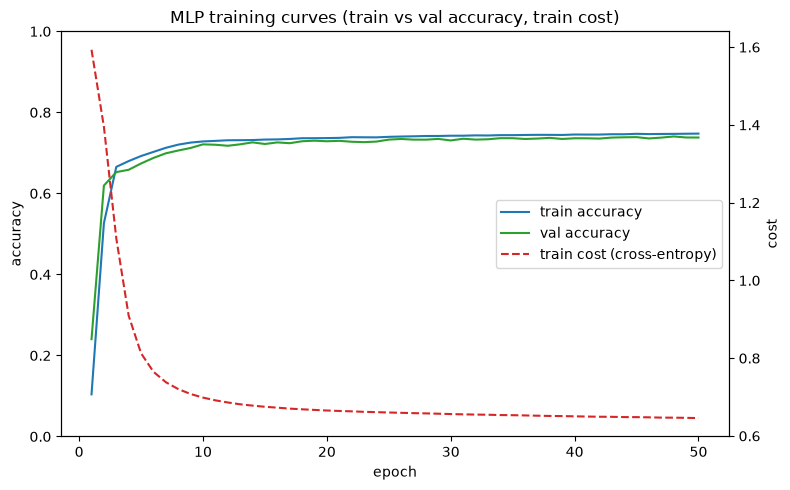

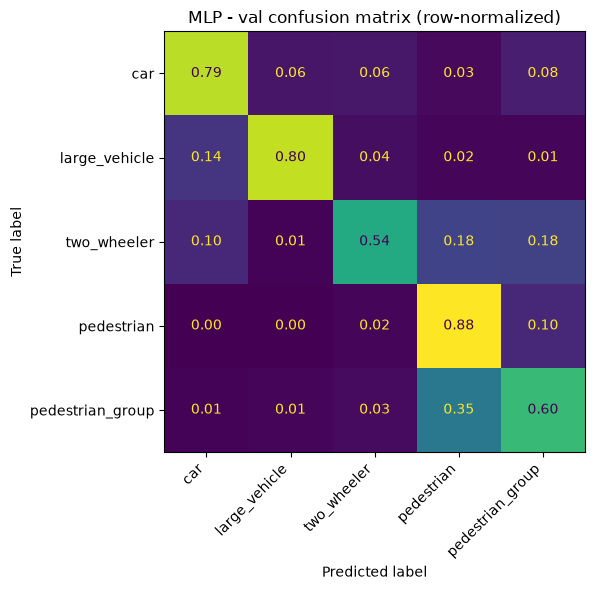

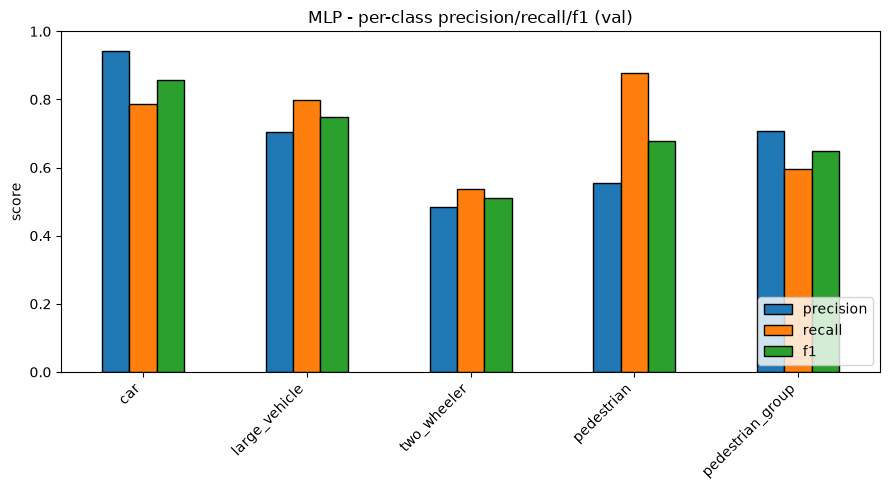

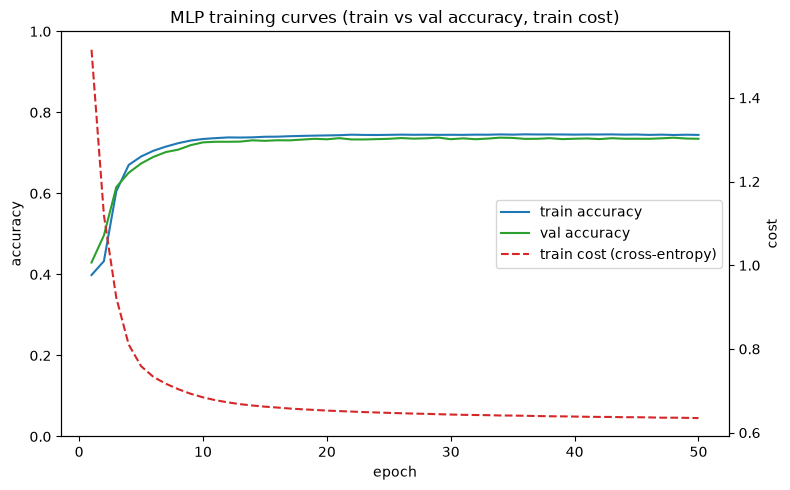

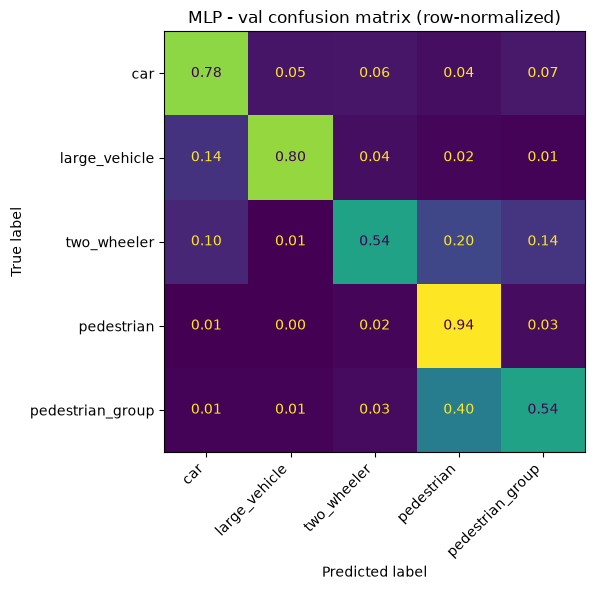

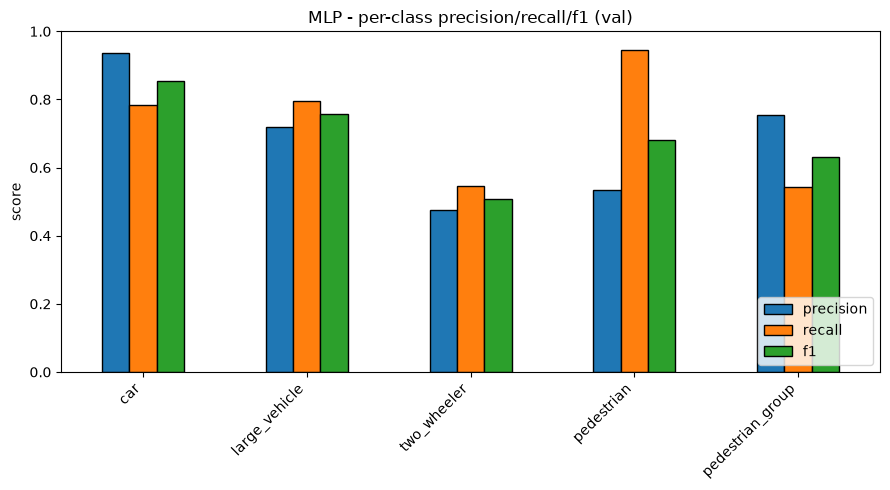

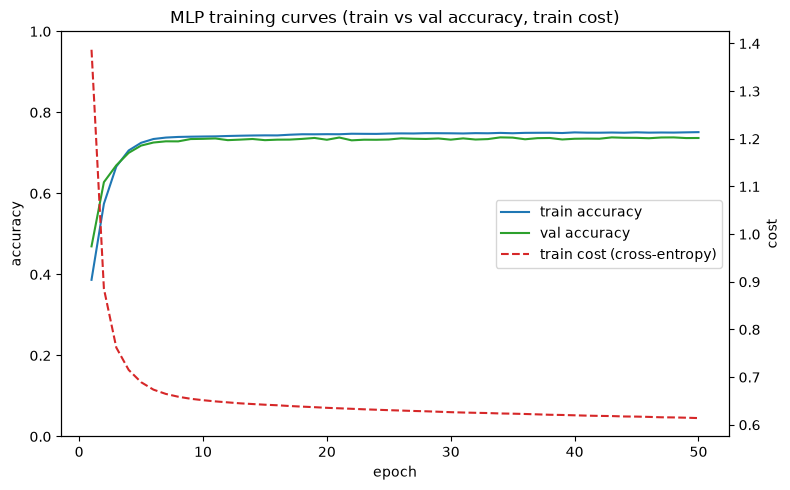

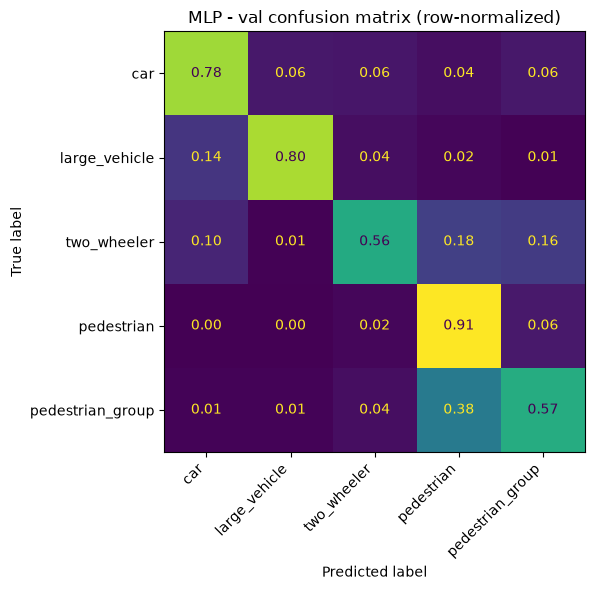

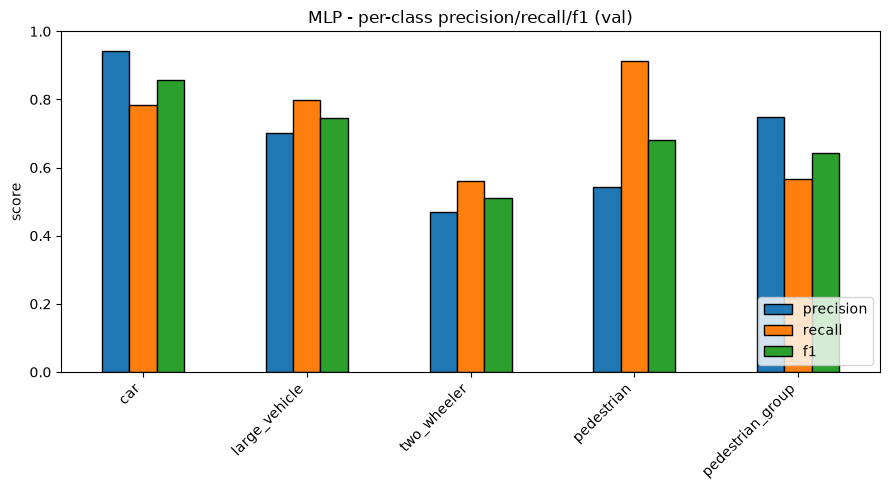

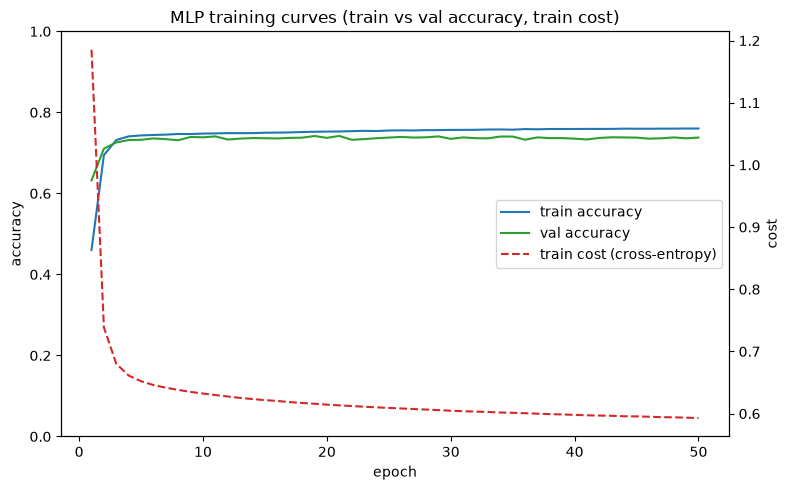

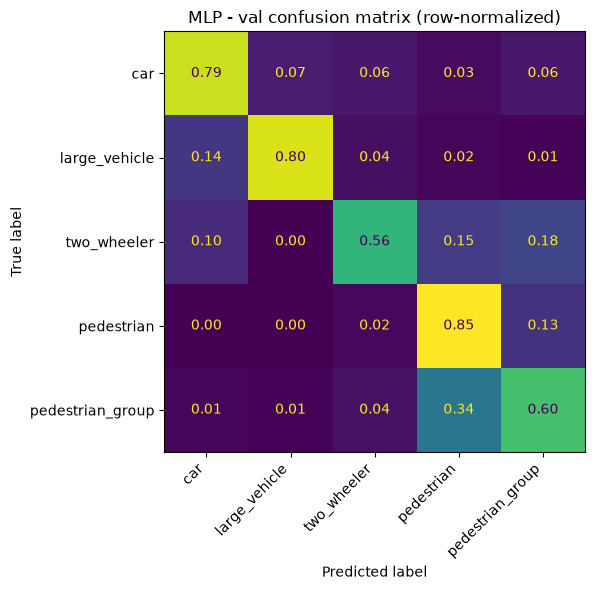

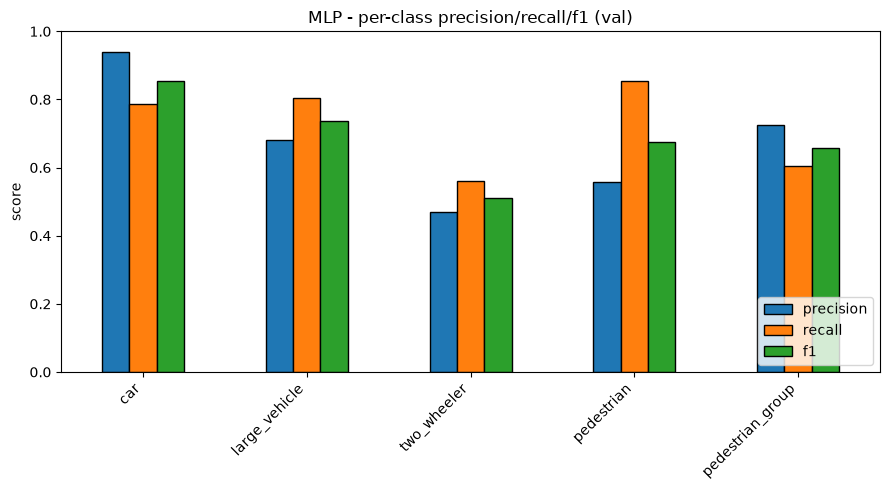

In [18]:
import json
from mlp_classifier import MLP_DIR

# cached, no retraining - per-class F1 by hidden_dim
hidden_per_class = {}
for variant in ["hidden8", "baseline", "hidden32", "hidden64"]:
    _, _, m, _, _ = run_variant(df, variant)
    hidden_per_class[variant] = m["f1"]
hidden_class_df = pd.DataFrame(hidden_per_class).T
hidden_spread = hidden_class_df.max() - hidden_class_df.min()

# cached val_metrics.json for each split-sensitivity fold - the noise reference
split_per_class = {}
for i in range(6):
    d = json.loads((MLP_DIR / "split_search" / f"fold_{i}" / "mlp_val_metrics.json").read_text())
    split_per_class[f"fold_{i}"] = {c: d[c]["f1"] for c in metrics_df.index}
split_class_df = pd.DataFrame(split_per_class).T
split_spread = split_class_df.max() - split_class_df.min()

pd.DataFrame({"hidden_dim spread (8-64)": hidden_spread, "split-choice spread (6 folds, noise reference)": split_spread})

No, not even per class. `pedestrian_group`'s hidden_dim spread (0.026) is the largest of any class, but that's still smaller than its own split-choice spread (0.117), and every other class shows the same pattern: whatever hidden_dim does to a class's F1 is dwarfed by what mere split choice already does to that same class. `two_wheeler` makes this starkest, spread of 0.005 from capacity against 0.386 from split choice alone. No class benefits from more or less capacity, the macro average wasn't hiding anything.

## Summary

| variant | macro F1 | notes |
|---|---|---|
| `bus_separate` (6 classes) | 0.611 | original taxonomy, superseded |
| `baseline` (5 classes, bus merged) | 0.686 | standing model |
| `truck_separate` (7 classes) | 0.541 | confirms truck merge was correct |
| `range_sc` | 0.704 | looked better, confirmed noise (see split sensitivity) |
| `bs32` | 0.687 | no real difference from baseline |
| `hidden8`/`hidden32`/`hidden64` | 0.688 / 0.688 / 0.688 | no capacity effect, feature ceiling not model ceiling |
| split sensitivity, 6 valid splits | 0.651 - 0.734 | noise floor for any single-split comparison here |

Standing model: `baseline`, 5 classes, `BATCH_SIZE=128`, `EPOCHS=50`, `HIDDEN_DIM=16`, `doppler_spread` feature set. Anything smaller than roughly a 3 point macro F1 gap shouldn't be trusted from a single split.

Full writeup, reasoning, and the general lesson on split sensitivity: `MLP_Decisions_and_Findings.md`.